In [7]:
import xarray as xr
import rioxarray as rxr
from odc.geo.xr import ODCExtensionDa
from odc.geo.geobox import GeoboxTiles

In [2]:
import zipfile
import tempfile
import xarray as xr
import shutil

zip_path = "/scicore/home/meiera/schulz0022/projects/growth-and-temperature/data_nobackup/esacci/landcover/raw/1992/ESACCI-LC-L4-LCCS-Map-300m-P1Y-1992-v2.0.7.nc"

with zipfile.ZipFile(zip_path) as z:
    nc_name = [n for n in z.namelist() if n.endswith(".nc")][0]
    with tempfile.NamedTemporaryFile(suffix=".nc") as tmp:
        with z.open(nc_name) as f:
            shutil.copyfileobj(f, tmp)
        tmp.flush()
        ds = xr.open_dataset(tmp.name, engine="h5netcdf", decode_coords="all")

In [3]:
ds = ds[["lccs_class"]]

In [12]:
ds = ds.odc.assign_crs(4326)

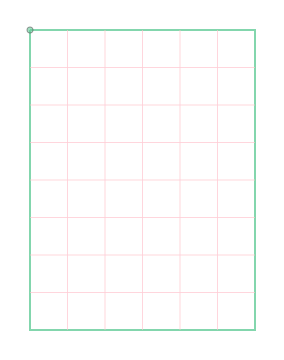

In [15]:
GeoboxTiles(ds.odc.geobox, [1000, 1000])[-1,-1]

In [7]:
ds.drop_vars(["processed_flag"])

<xarray.Dataset> Size: 67GB
Dimensions:              (time: 1, lat: 64800, lon: 129600, bounds: 2)
Coordinates:
  * lat                  (lat) float64 518kB 90.0 90.0 89.99 ... -90.0 -90.0
  * lon                  (lon) float64 1MB -180.0 -180.0 -180.0 ... 180.0 180.0
    lat_bounds           (lat, bounds) float64 1MB ...
    lon_bounds           (lon, bounds) float64 2MB ...
    time_bounds          (time, bounds) datetime64[ns] 16B ...
  * time                 (time) datetime64[ns] 8B 1992-01-01
Dimensions without coordinates: bounds
Data variables:
    lccs_class           (time, lat, lon) uint8 8GB ...
    current_pixel_state  (time, lat, lon) float32 34GB ...
    observation_count    (time, lat, lon) uint16 17GB ...
    change_count         (time, lat, lon) uint8 8GB ...
    crs                  int32 4B ...
Attributes: (12/38)
    id:                         ESACCI-LC-L4-LCCS-Map-300m-P1Y-1992-v2.0.7cds
    title:                      Land Cover Map of ESA CCI brokered by CDS
    summary:                    This dataset characterizes the land cover of ...
    type:                       ESACCI-LC-L4-LCCS-Map-300m-P1Y
    project:                    Climate Change Initiative - European Space Ag...
    references:                 http://www.esa-landcover-cci.org/
    ...                         ...
    geospatial_lon_max:         180
    spatial_resolution:         300m
    geospatial_lat_units:       degrees_north
    geospatial_lat_resolution:  0.002778
    geospatial_lon_units:       degrees_east
    geospatial_lon_resolution:  0.002778

In [5]:
(ds.head(10000).lccs_class == 0).mean()

<xarray.DataArray 'lccs_class' ()> Size: 8B
array(0.)

In [4]:
ds.head(10000).processed_flag.mean()

<xarray.DataArray 'processed_flag' ()> Size: 8B
array(0.16777216)

In [ ]:
ds.where(processed_flag)

In [10]:
ds.processed_flag.mean()

: 

: 

: 

In [7]:
ds.processed_flag.head().values

array([[[0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0.]]], dtype=float32)

In [8]:
ds.lccs_class#.head().values

<xarray.DataArray 'lccs_class' (time: 1, lat: 64800, lon: 129600)> Size: 8GB
[8398080000 values with dtype=uint8]
Coordinates:
  * lat      (lat) float64 518kB 90.0 90.0 89.99 89.99 ... -89.99 -90.0 -90.0
  * lon      (lon) float64 1MB -180.0 -180.0 -180.0 -180.0 ... 180.0 180.0 180.0
  * time     (time) datetime64[ns] 8B 1992-01-01
Attributes:
    standard_name:        land_cover_lccs
    flag_colors:          #ffff64 #ffff64 #ffff00 #aaf0f0 #dcf064 #c8c864 #00...
    long_name:            Land cover class defined in LCCS
    valid_min:            1
    valid_max:            220
    ancillary_variables:  processed_flag current_pixel_state observation_coun...
    flag_meanings:        no_data cropland_rainfed cropland_rainfed_herbaceou...
    flag_values:          [  0  10  11  12  20  30  40  50  60  61  62  70  7...

In [5]:
ds.processed_flag.head()

<xarray.DataArray 'processed_flag' (time: 1, lat: 5, lon: 5)> Size: 100B
[25 values with dtype=float32]
Coordinates:
  * lat      (lat) float64 40B 90.0 90.0 89.99 89.99 89.99
  * lon      (lon) float64 40B -180.0 -180.0 -180.0 -180.0 -180.0
  * time     (time) datetime64[ns] 8B 1992-01-01
Attributes:
    long_name:      LC map processed area flag
    standard_name:  land_cover_lccs status_flag
    valid_min:      0
    valid_max:      1
    flag_meanings:  not_processed processed
    flag_values:    [0 1]

In [8]:
ds.processed_flag.head().values

array([[[0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0.]]], dtype=float32)

In [7]:
ds.lccs_class.head().where(ds.processed_flag.head() == 1)

<xarray.DataArray 'lccs_class' (time: 1, lat: 5, lon: 5)> Size: 100B
array([[[nan, nan, nan, nan, nan],
        [nan, nan, nan, nan, nan],
        [nan, nan, nan, nan, nan],
        [nan, nan, nan, nan, nan],
        [nan, nan, nan, nan, nan]]], dtype=float32)
Coordinates:
  * lat      (lat) float64 40B 90.0 90.0 89.99 89.99 89.99
  * lon      (lon) float64 40B -180.0 -180.0 -180.0 -180.0 -180.0
  * time     (time) datetime64[ns] 8B 1992-01-01
Attributes:
    standard_name:        land_cover_lccs
    flag_colors:          #ffff64 #ffff64 #ffff00 #aaf0f0 #dcf064 #c8c864 #00...
    long_name:            Land cover class defined in LCCS
    valid_min:            1
    valid_max:            220
    ancillary_variables:  processed_flag current_pixel_state observation_coun...
    flag_meanings:        no_data cropland_rainfed cropland_rainfed_herbaceou...
    flag_values:          [  0  10  11  12  20  30  40  50  60  61  62  70  7...

In [2]:
ds.lccs_class.head().astype("float16")

NameError: name 'ds' is not defined

---

In [33]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import to_rgb

In [3]:
stage_2 = xr.open_zarr(
    "/scicore/home/meiera/schulz0022/projects/growth-and-temperature/data_nobackup/esacci/landcover/processed/stage_2/esacci_lc_timeseries_reprojected.zarr",
    zarr_format=3, consolidated=False, chunks="auto"
    )

In [35]:
subset = stage_2.isel(latitude=slice(10000,11000), longitude=slice(40500,41500)).compute()

In [36]:
hex_color_dict = {subset.lccs_class.attrs["flag_values"][ix]: col for ix, col in enumerate(subset.lccs_class.attrs["flag_colors"].split(" "))}
rgb_color_dict = {key: np.array(to_rgb(val)) for key, val in hex_color_dict.items()}

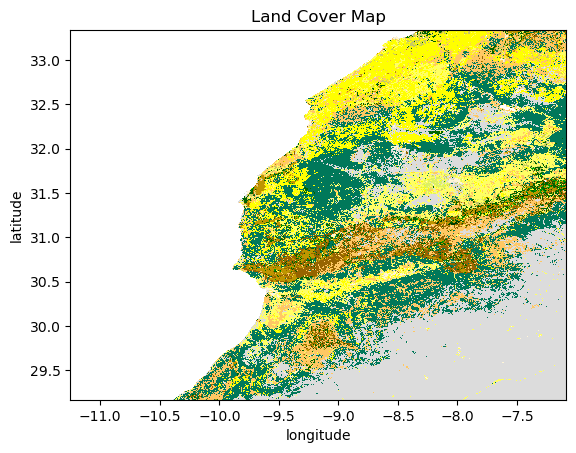

In [38]:
year = 2000
da = subset.lccs_class.sel(time=f"{year}-12-31").squeeze()

# --- Map matrix values → RGB image (H x W x 3) ---
data = da.values
rgb_image = np.zeros((*data.shape, 3), dtype=float)
for val, rgb in rgb_color_dict.items():
    rgb_image[data == val] = rgb

# --- Wrap back as xarray for labeled axes (optional) ---
rgb_da = xr.DataArray(
    rgb_image,
    dims=["latitude", "longitude", "rgb"],
    coords={"latitude": da.coords["latitude"], "longitude": da.coords["longitude"]}
)

# --- Plot ---
rgb_da.plot.imshow(rgb="rgb")
plt.title("Land Cover Map")
plt.show()

In [63]:
year_start = 1992; year_end = 2020
da_start = subset.lccs_class.sel(
    latitude=slice(31, 30), 
    longitude=slice(-10,-8), 
    time=f"{year_start}-12-31").squeeze()
da_end = subset.lccs_class.sel(
    latitude=slice(31, 30), 
    longitude=slice(-10,-8), 
    time=f"{year_end}-12-31"
    ).squeeze()

In [ ]:
from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch

# --- Colormap 1: Transparent background + Blue (Okabe-Ito #0072B2) ---
cmap1 = ListedColormap(["none", "#0072B2"])  # Blue

# --- Colormap 2: Transparent background + Vermillion (Okabe-Ito #D55E00) ---
cmap2 = ListedColormap(["none", "#D55E00"])  # Vermillion (red-orange)


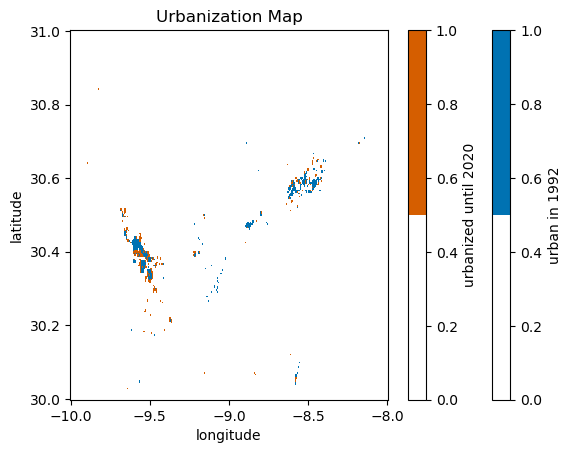

In [66]:
fig, ax = plt.subplots()
# --- Plot ---
(da_start == 190).rename("urban in 1992").plot.imshow(ax=ax, cmap=cmap1)
((da_end == 190) & ~(da_start == 190)).rename("urbanized until 2020").plot.imshow(ax=ax, cmap=cmap2)
plt.title("Urbanization Map")
plt.show()